<a href="https://colab.research.google.com/github/AnubhabBiswas123/Basic-C-Programming/blob/main/Denoising_Sparse_Encoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import regularizers
from skimage.metrics import peak_signal_noise_ratio as psnr
from sklearn.metrics import mean_squared_error

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), 28*28))
x_test = x_test.reshape((len(x_test), 28*28))

In [4]:
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

In [5]:
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

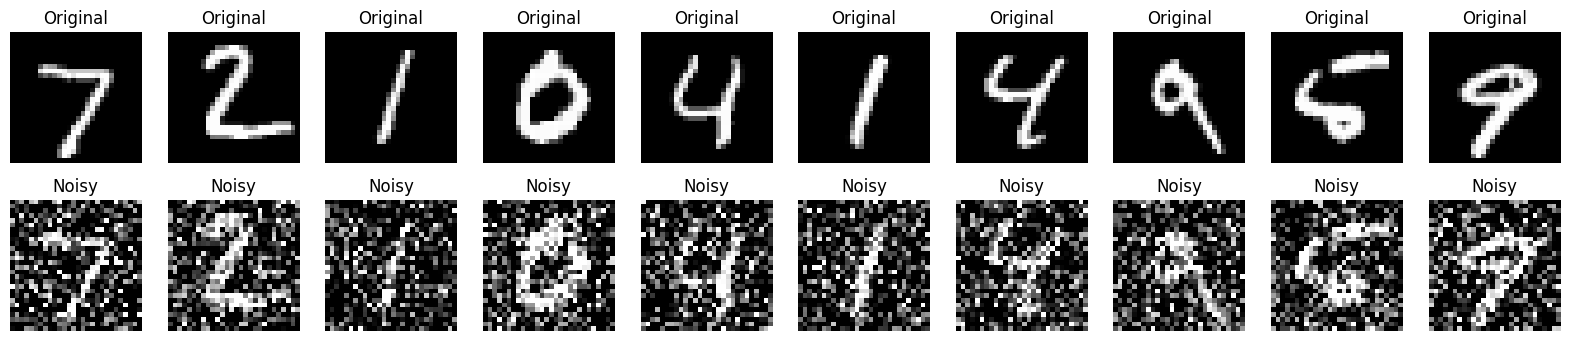

In [6]:
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
 ax = plt.subplot(2, n, i + 1)
 plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
 plt.title("Original")
 plt.axis('off')

 ax = plt.subplot(2, n, i + 1 + n)
 plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
 plt.title("Noisy")
 plt.axis('off')
plt.show()

In [7]:
input_dim = 784
encoding_dim = 64

In [8]:
input_img = tf.keras.Input(shape=(input_dim,))
encoded = layers.Dense(256, activation='relu')(input_img)
encoded = layers.Dense(128, activation='relu')(encoded)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)

decoded = layers.Dense(128, activation='relu')(encoded)
decoded = layers.Dense(256, activation='relu')(decoded)
decoded = layers.Dense(input_dim, activation='sigmoid')(decoded)

In [9]:
autoencoder = tf.keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [10]:
history = autoencoder.fit(
x_train_noisy, x_train,
epochs=20,
batch_size=256,
shuffle=True,
validation_data=(x_test_noisy, x_test)
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.3139 - val_loss: 0.1812
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1728 - val_loss: 0.1532
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.1504 - val_loss: 0.1409
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.1400 - val_loss: 0.1339
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.1336 - val_loss: 0.1305
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1299 - val_loss: 0.1272
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.1266 - val_loss: 0.1254
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1238 - val_loss: 0.1230
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.1217 - val_loss: 0.1210
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.1198 - val_loss: 0.1190
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.1178 - val_loss: 0.1181
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


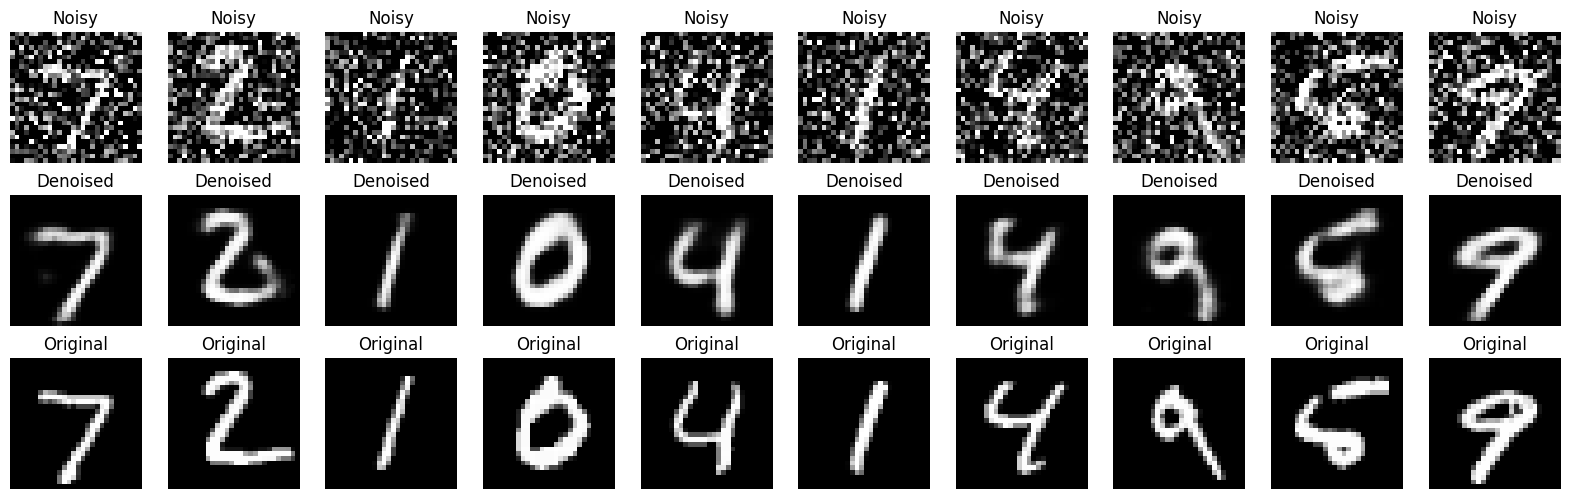

In [11]:
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
 ax = plt.subplot(3, n, i + 1)
 plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
 plt.title("Noisy")
 plt.axis('off')

 decoded_imgs = autoencoder.predict(x_test_noisy)
 ax = plt.subplot(3, n, i + 1 + n)
 plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
 plt.title("Denoised")
 plt.axis('off')


 ax = plt.subplot(3, n, i + 1 + 2*n)
 plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
 plt.title("Original")
 plt.axis('off')
plt.show()

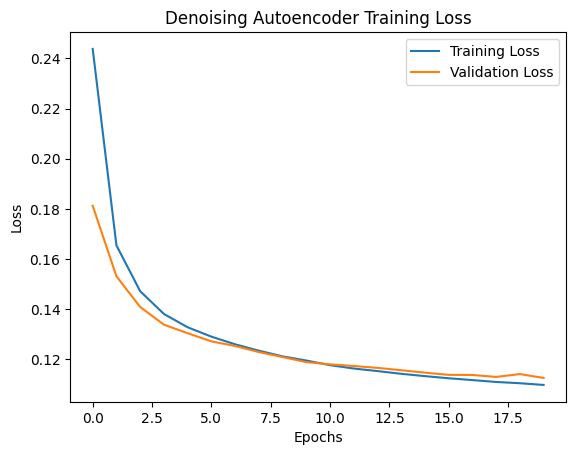

In [12]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Denoising Autoencoder Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [13]:
input_dim = 784
encoding_dim = 64

In [14]:
input_img = tf.keras.Input(shape=(input_dim,))

encoded = layers.Dense(256, activation='relu')(input_img)
encoded = layers.Dense(128, activation='relu')(encoded)
encoded = layers.Dense(encoding_dim, activation='relu',
activity_regularizer=regularizers.l1(1e-5))(encoded)

decoded = layers.Dense(128, activation='relu')(encoded)
decoded = layers.Dense(256, activation='relu')(decoded)
decoded = layers.Dense(input_dim, activation='sigmoid')(decoded)

In [15]:
sparse_autoencoder = tf.keras.Model(input_img, decoded)
sparse_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [16]:
history_sparse = sparse_autoencoder.fit(
x_train, x_train,
epochs=20,
batch_size=256,
shuffle=True,
validation_data=(x_test, x_test)
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - loss: 0.3662 - val_loss: 0.2168
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.2104 - val_loss: 0.1926
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.1907 - val_loss: 0.1842
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.1826 - val_loss: 0.1744
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: 0.1734 - val_loss: 0.1691
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.1685 - val_loss: 0.1637
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.1629 - val_loss: 0.1588
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.1580 - val_loss: 0.1559
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 0.1557 - val_loss: 0.1531
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.1533 - val_loss: 0.1512
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.1509 - val_loss: 0.1495
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


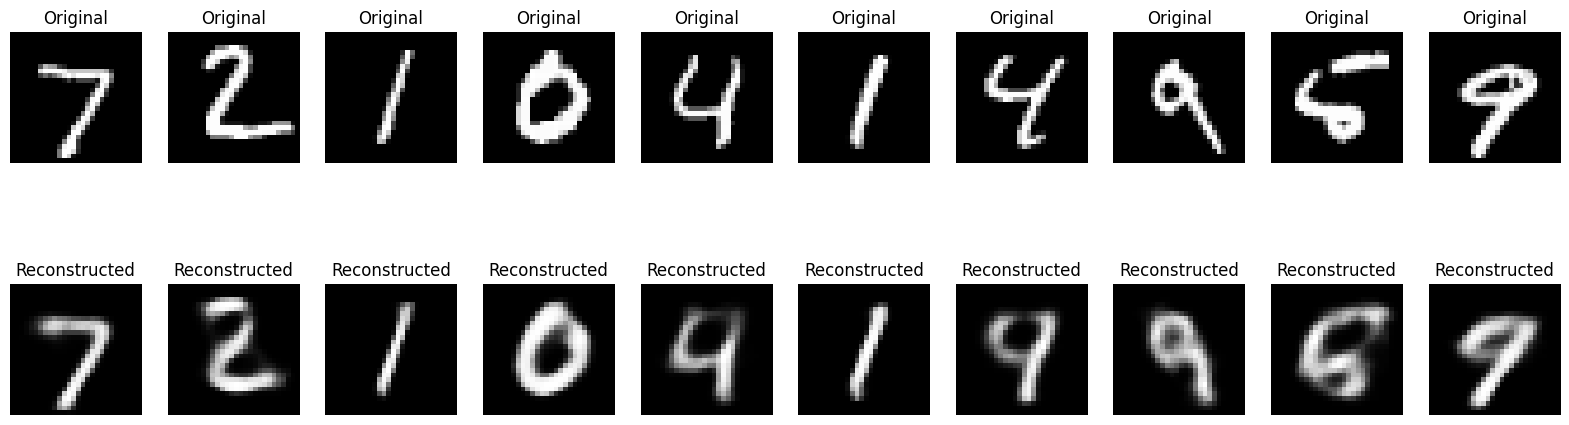

In [17]:
n = 10

decoded_imgs_sparse = sparse_autoencoder.predict(x_test)
plt.figure(figsize=(20, 6))
for i in range(n):
 ax = plt.subplot(2, n, i + 1)
 plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
 plt.title("Original")
 plt.axis('off')
 ax = plt.subplot(2, n, i + 1 + n)
 plt.imshow(decoded_imgs_sparse[i].reshape(28, 28), cmap='gray')
 plt.title("Reconstructed")
 plt.axis('off')
plt.show()

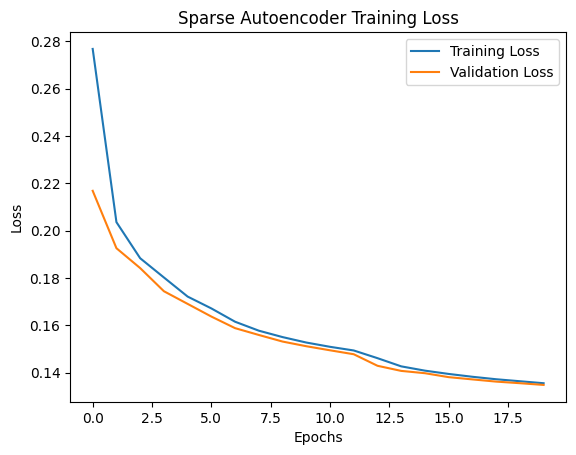

In [18]:
plt.plot(history_sparse.history['loss'], label='Training Loss')
plt.plot(history_sparse.history['val_loss'], label='Validation Loss')
plt.title('Sparse Autoencoder Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

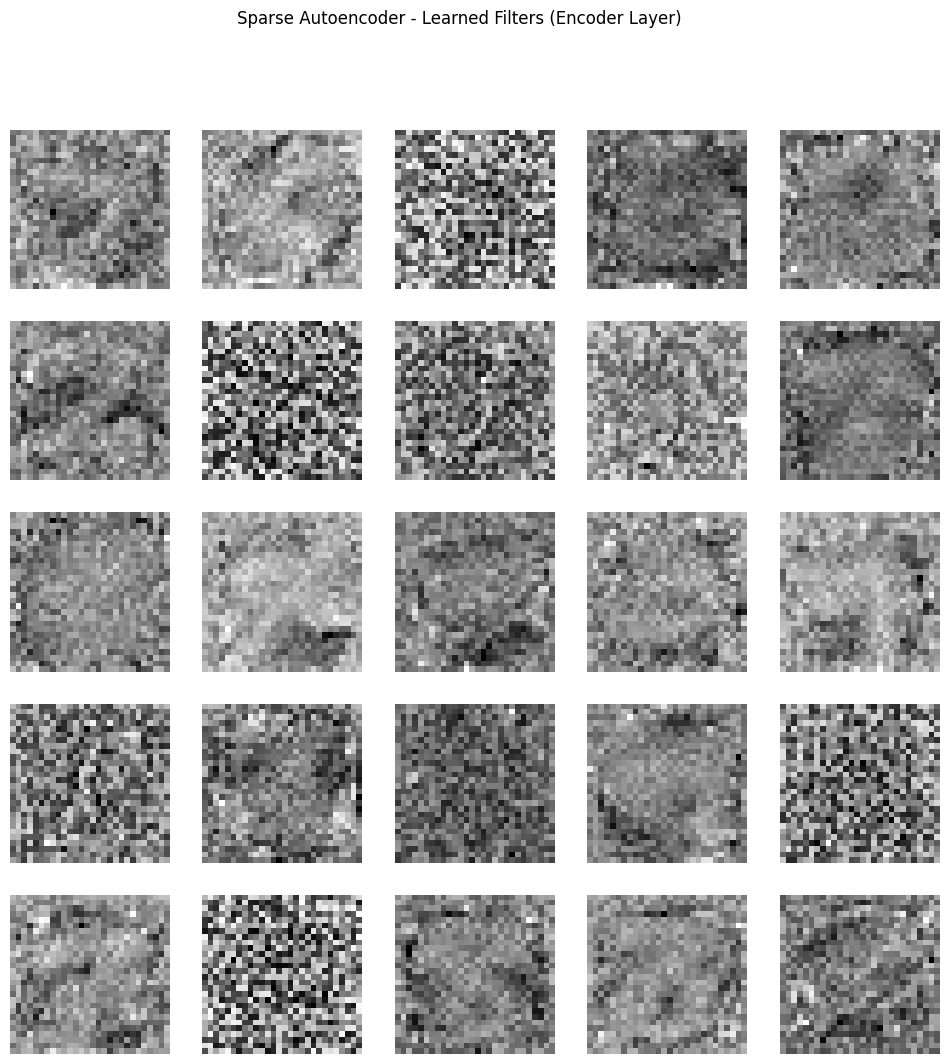

In [19]:
weights, biases = sparse_autoencoder.layers[1].get_weights()
plt.figure(figsize=(12, 12))
for i in range(25):
 ax = plt.subplot(5, 5, i + 1)
 plt.imshow(weights[:, i].reshape(28, 28), cmap='gray')
 plt.axis('off')
 plt.suptitle('Sparse Autoencoder - Learned Filters (Encoder Layer)')
plt.show()

In [20]:
decoded_denoised = autoencoder.predict(x_test_noisy)
decoded_sparse = sparse_autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [21]:
mse_denoised = mean_squared_error(x_test.flatten(), decoded_denoised.flatten())
psnr_denoised = psnr(x_test, decoded_denoised)

In [22]:
mse_denoised = mean_squared_error(x_test.flatten(), decoded_denoised.flatten())
psnr_denoised = psnr(x_test, decoded_denoised)


mse_sparse = mean_squared_error(x_test.flatten(), decoded_sparse.flatten())
psnr_sparse = psnr(x_test, decoded_sparse)

In [23]:
print("===== Quantitative Evaluation =====")
print(f"Denoising Autoencoder -> MSE: {mse_denoised:.6f}, PSNR: {psnr_denoised:.2f} dB")
print(f"Sparse Autoencoder -> MSE: {mse_sparse:.6f}, PSNR: {psnr_sparse:.2f} dB")

===== Quantitative Evaluation =====
Denoising Autoencoder -> MSE: 0.016509, PSNR: 17.82 dB
Sparse Autoencoder -> MSE: 0.022990, PSNR: 16.38 dB


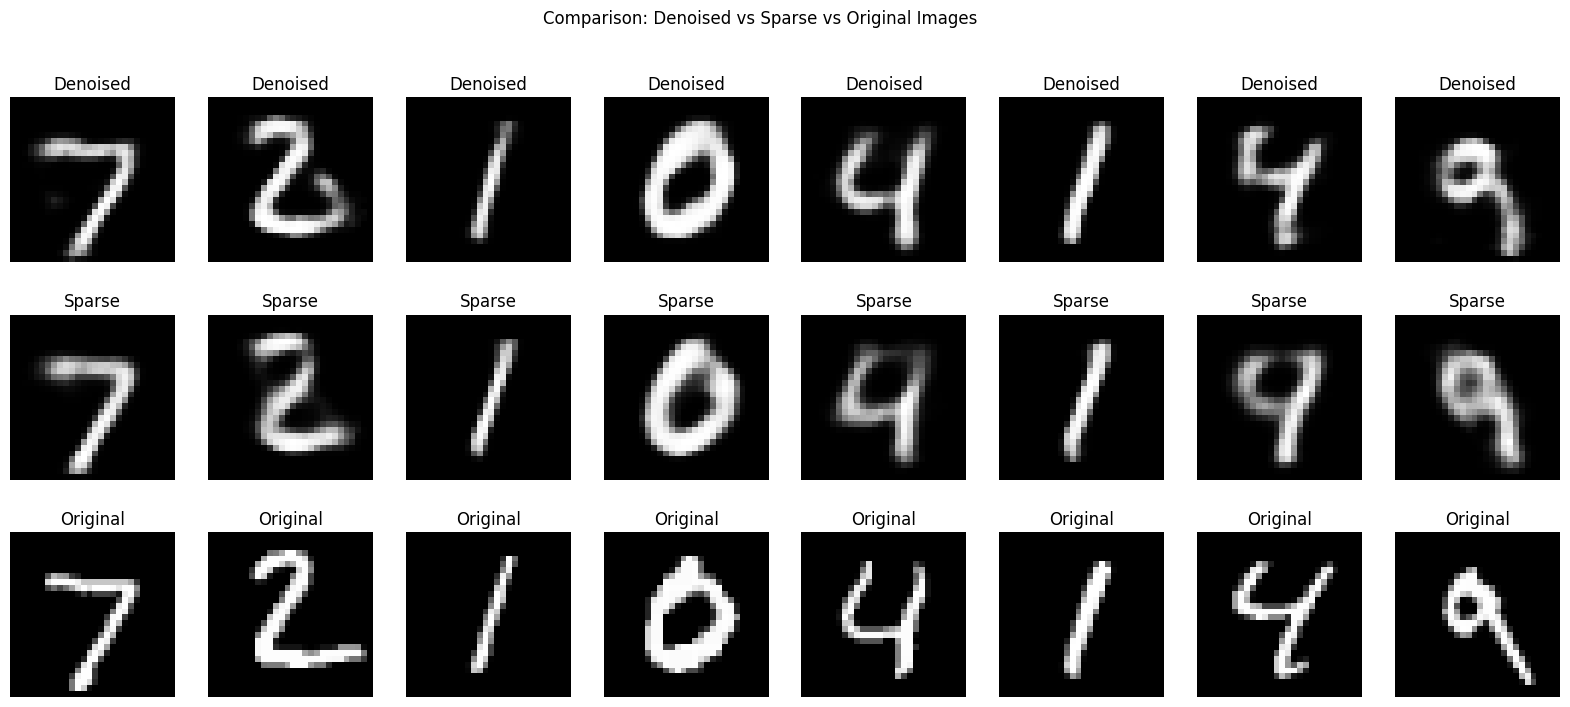

In [24]:
n = 8
plt.figure(figsize=(20, 8))
for i in range(n):
 ax = plt.subplot(3, n, i + 1)
 plt.imshow(decoded_denoised[i].reshape(28, 28), cmap='gray')
 plt.title("Denoised")
 plt.axis('off')

 ax = plt.subplot(3, n, i + 1 + n)
 plt.imshow(decoded_sparse[i].reshape(28, 28), cmap='gray')
 plt.title("Sparse")
 plt.axis('off')

 ax = plt.subplot(3, n, i + 1 + 2*n)
 plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
 plt.title("Original")
 plt.axis('off')


 plt.suptitle('Comparison: Denoised vs Sparse vs Original Images')
plt.show()

In [25]:
print("\n===== Observations =====")
print("1️⃣ Denoising Autoencoder reduces random noise effectively while retaining global structure.")
print("2️⃣ Sparse Autoencoder learns compact, meaningful features that improve interpretability.")
print("3️⃣ Denoising performs better in reconstruction metrics, while sparse models show structured feature learning.")


===== Observations =====
1️⃣ Denoising Autoencoder reduces random noise effectively while retaining global structure.
2️⃣ Sparse Autoencoder learns compact, meaningful features that improve interpretability.
3️⃣ Denoising performs better in reconstruction metrics, while sparse models show structured feature learning.
